## Executive Summary

The Supplemental Nutrition Assistance Program [(SNAP)](https://www.ers.usda.gov/topics/food-nutrition-assistance/supplemental-nutrition-assistance-program-snap/key-statistics-and-research) exists to support  millions of Americans struggling with food insecurity. This program alleviates hardships when families face unemployment and poverty, and its contribution to stabilizing demand during a recession is crucial to the American economy. Putting SNAP in the context of other economic and societal indicators, analyzing its trends over time, and understanding it as a program with various advantages, demonstrates its real value. This project aims to examine SNAP trends at length, looking at participation rates, spending, and impacts of the program by utilizing data from the United States Department of Agriculture (USDA) and the Bureau of Labor Statistics (BLS). Through multiple visualizations, we hope to better understand the SNAP trends, the program, and why it matters. 

## Background

In the United States, 48 million people face food insecurity. This means that 1 in 7 households are food insecure, and nearly 14 million kids don't have consistent access to daily meals [(Feeding America)](https://www.feedingamerica.org/hunger-in-america). Hunger exists everywhere, even in high-income countries like the United States, and can be caused by a variety of factors. From where we live to the cost of living, hunger creates health challenges and barriers to the future that are hard to break and overcome. 

The Supplemental Nutrition Assistance Program (SNAP, formerly called Food Stamps) exists to support the millions of Americans struggling to afford food. The SNAP program has existed for 60 years, reaching vulnerable populations with federal funds that are state administrered and is designed to be countercyclical [(Harvard)](https://www.hks.harvard.edu/faculty-research/policy-topics/social-policy/explainer-understanding-snap-program-and-what-cuts). As the economy worsens, during periods like the Great Recession or the COVID-19 pandemic, SNAP enrollment is meant to increase, mitigating the impact that economic downturn has on the economy and alleviating costs to families and consumers. More or less, it acts as an automatic stabilizer, expanding during downturns to support and stimulate the economy.

In turn, evidence has shown that SNAP has a positive impact on Americans. SNAP reduces food insecurity, helps local economies, and lifts families out of poverty. It is also highly correlated with indicators like employment status, income, household composition, health outcomes, and food security ([CBPP)](https://www.cbpp.org/research/food-assistance/snap-is-linked-with-improved-health-outcomes-and-lower-health-care-costs#:~:text=SNAP%20is%20associated%20with%20improved,to%20build%20upon%20its%20successes.). Given this, examining SNAP trends in the United States in relation to other indicators can illustrate the program's economic and societal impacts, as well as the contexts in which it benefits Americans.  

### Data Preparation

In [1]:
# Import Libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import sklearn as sk
import matplotlib.ticker as mtick
import math
import matplotlib.dates as mdates
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

In [2]:
SNAP_annual_summary_clean = pd.read_csv('/Users/avavannortwick/Desktop/Classes/DataViz/Midterm/DATA/snap-annualsummary-2.csv')

# Rename columns
SNAP_annual_summary_clean.columns = [
    "year",
    "participants_thousands",
    "avg_benefit",
    "total_benefits_millions",
    "other_costs_millions",
    "total_costs_millions"
]

# make an object with the columns we need in integers
cols_to_convert = [
    "participants_thousands",
    "avg_benefit",
    "total_benefits_millions",
    "other_costs_millions",
    "total_costs_millions"
]

# turn columns with STR to INT
for col in cols_to_convert:
    SNAP_annual_summary_clean[col] = (
        SNAP_annual_summary_clean[col]
        .astype(str)
        .str.replace(",", "")
    )
    SNAP_annual_summary_clean[col] = pd.to_numeric(SNAP_annual_summary_clean[col], errors="coerce")

# convert to more intuitive units for visualization
SNAP_annual_summary_clean["participants_millions"] = SNAP_annual_summary_clean["participants_thousands"] / 1000
SNAP_annual_summary_clean["total_benefits_billions"] = SNAP_annual_summary_clean["total_benefits_millions"] / 1000
SNAP_annual_summary_clean["total_costs_billions"] = SNAP_annual_summary_clean["total_costs_millions"] / 1000

SNAP_annual_summary_clean = SNAP_annual_summary_clean[[
    "year",
    "participants_millions",
    "total_benefits_billions",
    "total_costs_billions"
]]

SNAP_annual_summary_clean.head()

,year,participants_millions,total_benefits_billions,total_costs_billions
0,1969,2.878,0.2288,0.2505
1,1970,4.340,0.5497,0.5769
2,1971,9.368,1.5227,1.5759
3,1972,11.109,1.7973,1.8667
4,1973,12.166,2.1314,2.2074


**Table 1. SNAP Annual Summary (Selected Variables)**  

This table shows participation and spending trends over time, converted into more interpretable units (millions and billions).  

*Source: USDA Food and Nutrition Service*

<div style="border-left: 4px solid #d95f02; padding: 10px; background-color: #FFD580;">
<strong>Note:</strong><br>
1] Represents average monthly benefits per person.<br>
2] Includes administrative and program costs.<br>
3] Puerto Rico participated from 1975–1982, then transitioned to a separate program.
</div>

## Section 1: Longterm Context

### 1.1 SNAP Participation Over Time
SNAP participation has increased substantially over time, growing from fewer than 3 million participants in 1969 to over 40 million in recent years. This reflects both the program's expansion and its role in responding to economic need. We can see how SNAP participation has ebbed and flowed, but overall remains very high in recent times, mostly since the 2010's. 

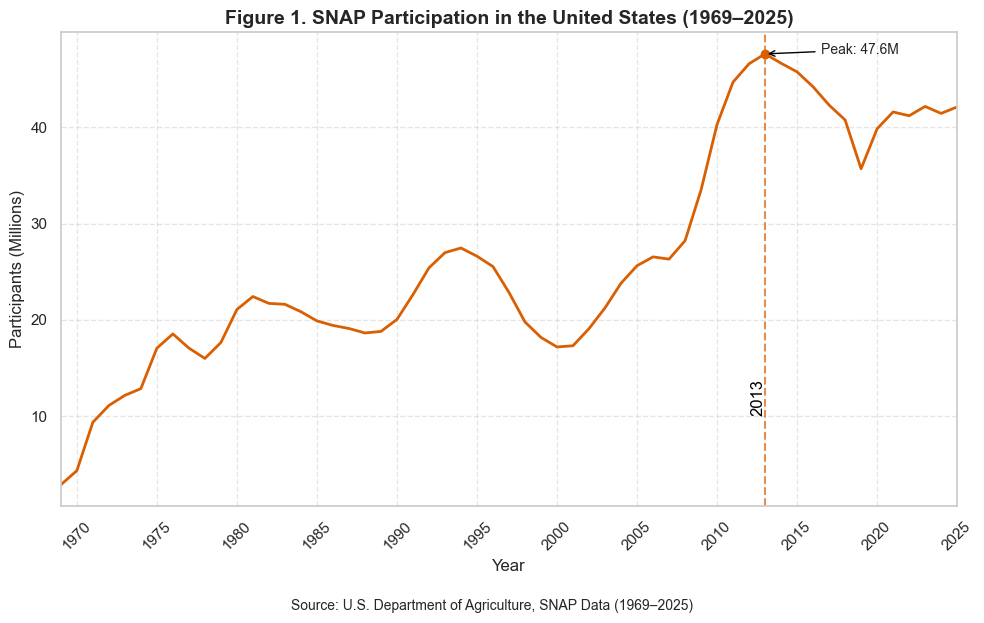

In [3]:
# Viz 1: SNAP Participation over time 

# Theme
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))
plt.plot(SNAP_annual_summary_clean["year"], SNAP_annual_summary_clean["participants_millions"], color="#d95f02", linewidth=2)

# Label
plt.title("Figure 1. SNAP Participation in the United States (1969–2025)", fontsize=14, weight="bold")
plt.xlabel("Year")
plt.ylabel("Participants (Millions)")
plt.xlim(SNAP_annual_summary_clean["year"].min(), SNAP_annual_summary_clean["year"].max())
plt.xticks(np.arange(1970, 2030, 5), rotation=45)

# add annotations
max_row = SNAP_annual_summary_clean.loc[SNAP_annual_summary_clean["participants_millions"].idxmax()]
plt.scatter(max_row["year"], max_row["participants_millions"], color="#d95f02")

plt.annotate(
    f"Peak: {max_row['participants_millions']:.1f}M",
    xy=(max_row["year"], max_row["participants_millions"]),   # where arrow points
    xytext=(max_row["year"] + 3.5, max_row["participants_millions"] + 0),  # where text sits
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=10
)

plt.axvline(2013, linestyle="--", alpha=0.7, color = "#d95f02")
plt.text(2013, 10, "2013", rotation=90, ha='right',va='bottom', color='black')

# add a caption
plt.figtext(
    0.5, -0.03,
    "Source: U.S. Department of Agriculture, SNAP Data (1969–2025)",
    ha="center",
    fontsize=10
)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("snap_participation_trend.png", dpi=300, bbox_inches="tight")
plt.show()

### 1.2 SNAP Spending Over Time

SNAP spending has grown alongside participation, with particularly sharp increases during periods of economic disruption. This reflects both increased enrollment and policy-driven changes to benefit levels. Examining SNAP spending over time can help us understand how its funding requirements have grown as participation in the program has increased. SNAP spending has currently been a topic of contention by the Trump Administration during the FY 2025 Budget process and the passing of the One Big Beautiful Bill Act (OBBBA), which supported various cuts to the program.

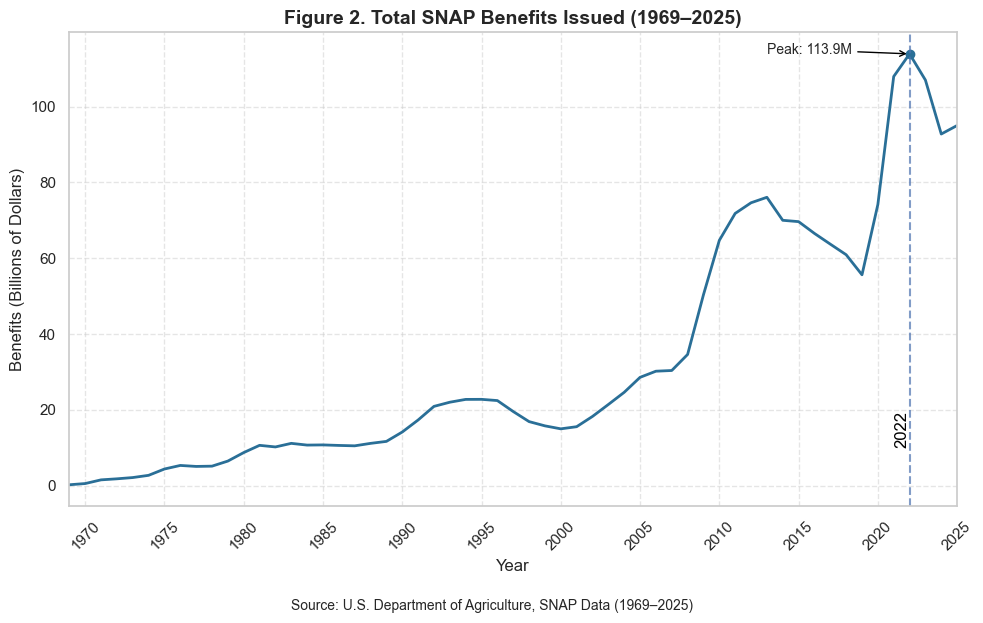

In [4]:
# Viz 2: SNAP Spending Over Time 

# Theme
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))
plt.plot(SNAP_annual_summary_clean["year"], SNAP_annual_summary_clean["total_benefits_billions"], color="#2a6f97", linewidth=2)

# Label
plt.title("Figure 2. Total SNAP Benefits Issued (1969–2025)", fontsize=14, weight="bold")
plt.xlabel("Year")
plt.ylabel("Benefits (Billions of Dollars)")
plt.xlim(SNAP_annual_summary_clean["year"].min(), SNAP_annual_summary_clean["year"].max())
plt.xticks(np.arange(1970, 2030, 5), rotation=45)

# add annotations
max_row = SNAP_annual_summary_clean.loc[SNAP_annual_summary_clean["total_benefits_billions"].idxmax()]
plt.scatter(max_row["year"], max_row["total_benefits_billions"], color="#2a6f97")

plt.annotate(
    f"Peak: {max_row['total_benefits_billions']:.1f}M",
    xy=(max_row["year"], max_row["total_benefits_billions"]),   # where arrow points
    xytext=(max_row["year"] - 9, max_row["total_benefits_billions"] - 0),  # where text sits
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=10
)

plt.axvline(2022, linestyle="--", alpha=0.7)
plt.text(2022, 10, "2022", rotation=90, ha='right',va='bottom', color='black')

# add a caption
plt.figtext(
    0.5, -0.03,
    "Source: U.S. Department of Agriculture, SNAP Data (1969–2025)",
    ha="center",
    fontsize=10
)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 1.3 Relationship between SNAP Participation and Spending Over Time

Participation and spending move together over time, but spending increases more sharply during certain periods, particularly during the COVID-19 pandemic. This suggests that policy changes—such as increased benefit levels—play an important role alongside participation in determining total program costs. Over time, the trend shows a general increase in both SNAP participation and spending since the conception fo the program, with a lot more funds being recently allocated. 

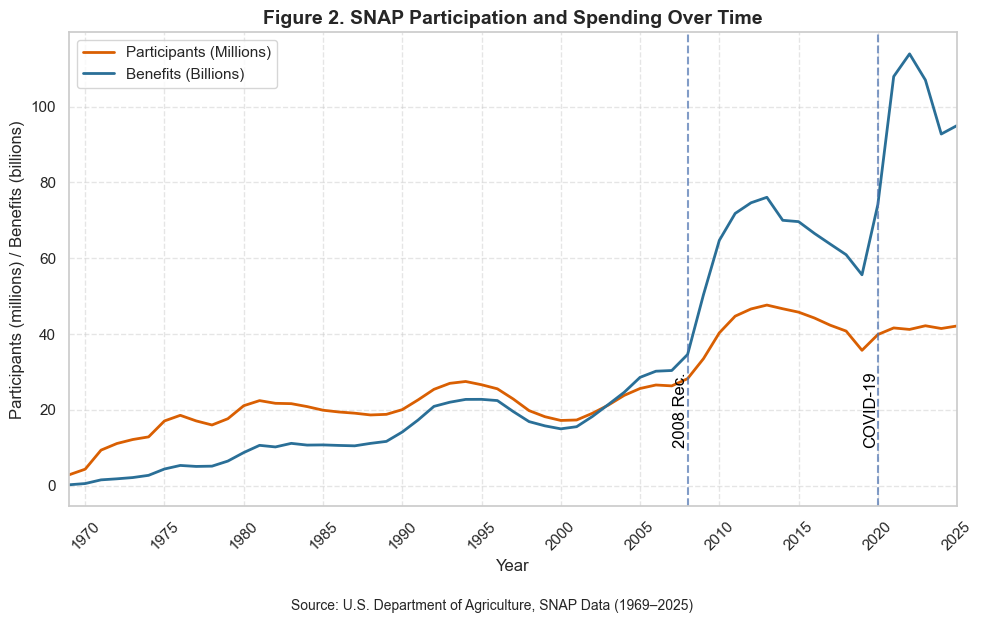

In [5]:
# Viz 3: SNAP Participation and Spending Over Time 

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))
plt.plot(SNAP_annual_summary_clean["year"], SNAP_annual_summary_clean["participants_millions"], label="Participants (Millions)", color="#d95f02", linewidth=2)
plt.plot(SNAP_annual_summary_clean["year"], SNAP_annual_summary_clean["total_benefits_billions"], label="Benefits (Billions)", color="#2a6f97", linewidth=2)

plt.title("Figure 2. SNAP Participation and Spending Over Time", fontsize=14, weight="bold")
plt.xlabel("Year")
plt.ylabel("Participants (millions) / Benefits (billions)")
plt.xlim(SNAP_annual_summary_clean["year"].min(), SNAP_annual_summary_clean["year"].max())
plt.xticks(np.arange(1970, 2030, 5), rotation=45)

plt.axvline(2008, linestyle="--", alpha=0.7)
plt.axvline(2020, linestyle="--", alpha=0.7)

plt.text(2008, 10, "2008 Rec.", rotation=90, ha='right',va='bottom', color='black')
plt.text(2020, 10, "COVID-19", rotation=90, ha='right', va='bottom', color='black')

# add a caption
plt.figtext(
    0.5, -0.03,
    "Source: U.S. Department of Agriculture, SNAP Data (1969–2025)",
    ha="center",
    fontsize=10
)

plt.legend(loc="upper left")  
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("snap_pands_trend.png", dpi=300, bbox_inches="tight")
plt.show()

## Section 2: Evidence from Economic Shocks

To better understand SNAP’s role as an automatic stabilizer, this section examines two major economic shocks—the Great Recession and the COVID-19 pandemic. By comparing SNAP participation with unemployment trends, we can observe how the program responds to changes in economic conditions. Specifically, in the section, the Great Recession and the COVID-19 Pandemic are the two events that will act as case studies to visualize the countercyclical nature of the SNAP program. 

In [6]:
Unemp_Data = pd.read_csv("/Users/avavannortwick/Desktop/Classes/DataViz/Midterm/DATA/snap_unemployment_poverty.csv")

# Prep our data, which is already pretty clean from the USDA
Unemp_Data.columns = [
    "year",
    "unemployment",
    "poverty",
    "snap_rate",
    "food_insecurity",
    "recession"
]

Unemp_Data.head()

,year,unemployment,poverty,snap_rate,food_insecurity,recession
0,1980,7.1,13.0,9.3,NaN,1
1,1981,7.6,14.0,9.8,NaN,1
2,1982,9.7,15.0,9.4,NaN,1
3,1983,9.6,15.2,9.2,NaN,1
4,1984,7.5,14.4,8.8,NaN,0


**Table 2. SNAP Indicators Summary** 

This table shows unemployment, poverty, food insecurity, and SNAP rate for the last 50 years. It also provides information on whether or not that year was considered a recession as defined by the Bureau of Labor Statistics (BLS). It has been converted into more interpretable units (millions and billions) for visualization purposes.  

*Source: USDA Food and Nutrition Service*

### 2.1 Relationship between SNAP Participation and Unemployment

SNAP participation closely tracks unemployment trends, increasing during periods of economic distress. This relationship is particularly visible during major downturns. We can examine SNAP Participation and Unemployment together to better understand the major causes for SNAP enrollment. 

When the U.S. economy faces economic hardship, Americans lose their jobs. When Americans are unemployed, they cannot pay for food on the table, and lack access to a stable income. The SNAP program must be able to expand to meet the needs of a greater number of participants during times of economic hardship. This data helps exemplify how SNAP reacts to periods of high unemployment. 

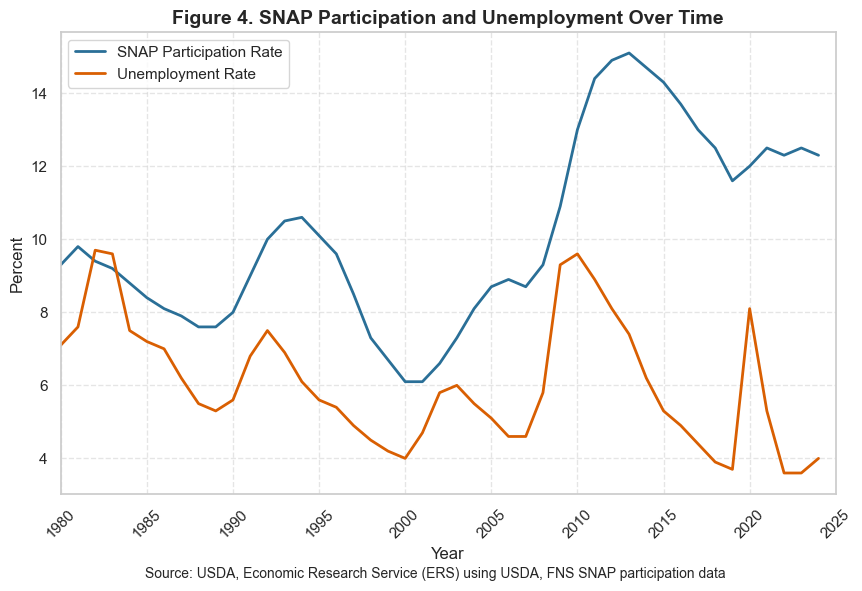

In [7]:
# Viz 4: SNAP vs. Unemployment 

# Theme + Sizing
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))

# Plotting
plt.plot(Unemp_Data["year"], Unemp_Data["snap_rate"], label="SNAP Participation Rate", color="#2a6f97", linewidth=2)
plt.plot(Unemp_Data["year"], Unemp_Data["unemployment"], label="Unemployment Rate", color="#d95f02", linewidth=2)

# Labeling
plt.title("Figure 4. SNAP Participation and Unemployment Over Time", fontsize=14, weight="bold")
plt.xlabel("Year")
plt.ylabel("Percent")

# Formatting
plt.xlim(Unemp_Data["year"].min(), Unemp_Data["year"].max())
plt.xticks(np.arange(1980, 2026, 5), rotation=45)

plt.legend()
plt.grid(alpha=0.3)

# Source caption
plt.figtext(
    0.5, -0.03,
    "Source: USDA, Economic Research Service (ERS) using USDA, FNS SNAP participation data",
    ha="center",
    fontsize=10
)

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

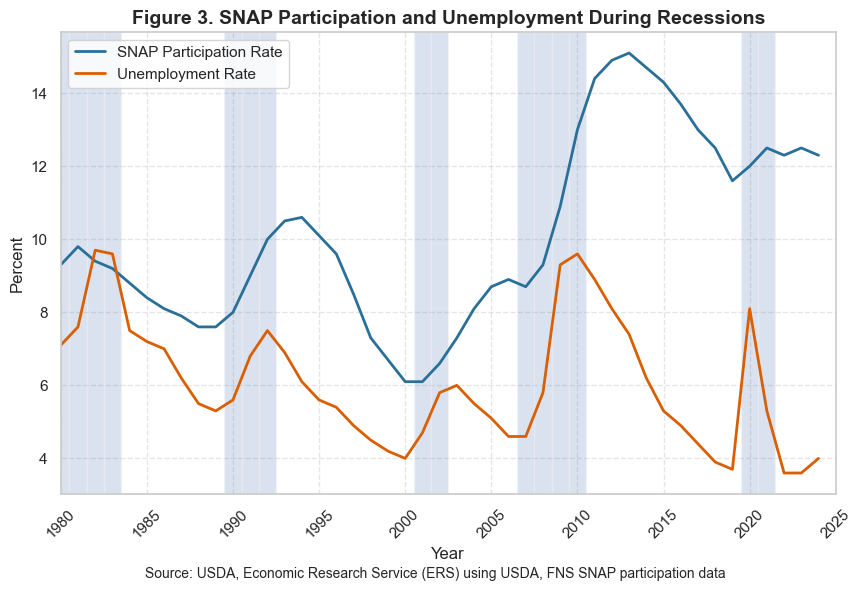

In [12]:
# Viz 5: SNAP vs. Unemployment During Recessions

# Theme + Sizing
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))

# Plotting
plt.plot(Unemp_Data["year"], Unemp_Data["snap_rate"], label="SNAP Participation Rate", color="#2a6f97", linewidth=2)
plt.plot(Unemp_Data["year"], Unemp_Data["unemployment"], label="Unemployment Rate", color="#d95f02", linewidth=2)

# Labeling
plt.title("Figure 3. SNAP Participation and Unemployment During Recessions", fontsize=14, weight="bold")
plt.xlabel("Year")
plt.ylabel("Percent")

# Formatting
plt.xlim(Unemp_Data["year"].min(), Unemp_Data["year"].max())
plt.xticks(np.arange(1980, 2026, 5), rotation=45)

plt.legend(loc="upper left")
plt.grid(alpha=0.3)

# shade recession years
for i in range(len(Unemp_Data)):
    if Unemp_Data["recession"].iloc[i] == 1:
        plt.axvspan(Unemp_Data["year"].iloc[i]-0.5, Unemp_Data["year"].iloc[i]+0.5, alpha=0.2)

# Source caption
plt.figtext(
    0.5, -0.03,
    "Source: USDA, Economic Research Service (ERS) using USDA, FNS SNAP participation data",
    ha="center",
    fontsize=10
)

plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig("snap_unemp_rec.png", dpi=300, bbox_inches="tight")
plt.show()

We can see in both Figure 4 and 5 that a lag exists between SNAP Participation and Unemployment decreasing; it takes longer for SNAP participation to decrease following Americans recovering from unemployment because there is a transition period between not having and receiving employment, where participants may still need some sort of financial relief. Figure 5 more directly highlights how SNAP Participation responds to periods of unemployment, specifically during recessions when unemployment spikes. 

### 2.2 The Great Recession

The Great Recession caused 8.7 million American job losses, doubled the unemployment rate to 10%, caused massive foreclosure rates, and saw the Dow Jones lose nearly half its value. Here, we take a closer look at how unemployment and SNAP participation move together as variables during an economic shock. During the early 2000's, SNAP participation and the unemployment rate were both low, but we can see this change around 2009, after the period of initial economic shock in 2008. Then, in 2010, when the high unemployment rate began to subside, we still saw SNAP participation occurring at a pretty high rate. This illustrates the "lag" between the two variables, which was previously discussed. 

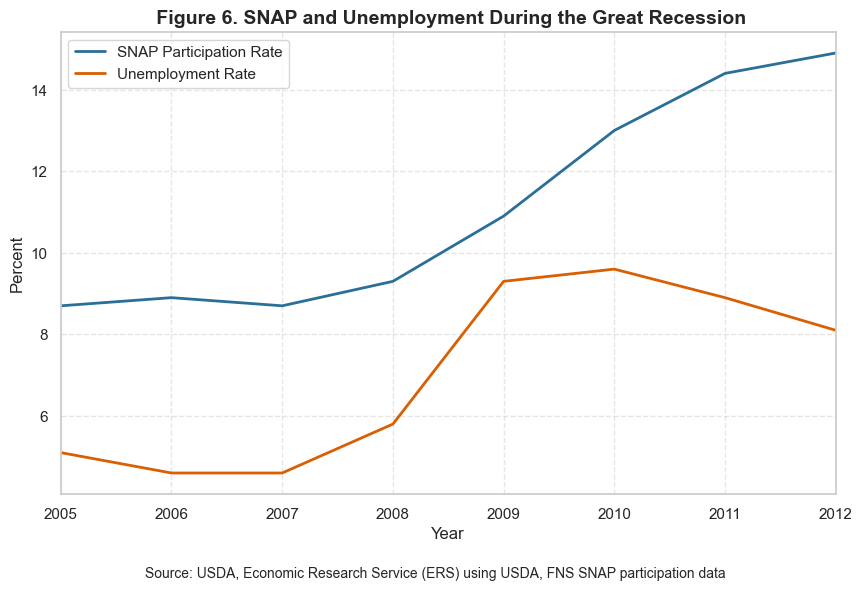

In [10]:
# Viz 6: Great Recession Zoom 

# Time Frame
GR = Unemp_Data[(Unemp_Data["year"] >= 2005) & (Unemp_Data["year"] <= 2012)]

# Theme + Sizing
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))

# Plotting
plt.plot(GR["year"], GR["snap_rate"], label="SNAP Participation Rate", color="#2a6f97", linewidth=2)
plt.plot(GR["year"], GR["unemployment"], label="Unemployment Rate", color="#d95f02", linewidth=2)

# Labeling
plt.title(" Figure 6. SNAP and Unemployment During the Great Recession", fontsize=14, weight="bold")
plt.xlabel("Year")
plt.ylabel("Percent")

# Formatting
plt.xlim(GR["year"].min(), GR["year"].max())
# plt.xticks(np.arange(2005, 2015, 5), rotation=45)

plt.legend()
plt.grid(alpha=0.3)

# Source caption
plt.figtext(
    0.5, -0.03,
    "Source: USDA, Economic Research Service (ERS) using USDA, FNS SNAP participation data",
    ha="center",
    fontsize=10
)

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 2.3 The COVID-19 Pandemic

COVID-19 caused a severe global economic crisis, driving the first rise in global poverty in a generation and worsening inequality across the world. Lockdowns triggered massive, disproportionate employment and income losses for women, youth, and lower-skilled workers. Smaller firms suffered more, while pandemic relief measures helped partially offset job losses. Here, we take a closer look at how unemployment and SNAP participation move together as variables during another economic shock, the COVID-19 pandemic. During early 2019, we saw a period of initial economic shock caused by the shutdown, as unemployment drastically rose. Then in 2020, when the unemployment rate began to decrease as society and the economy gradually opened up post-lockdown, we still saw SNAP participation at a high and constant rate.

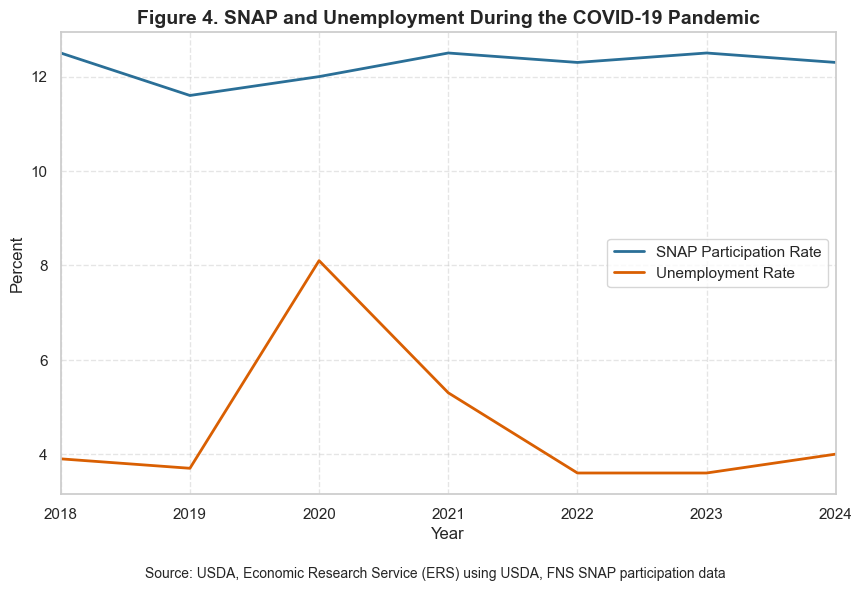

In [13]:
# Viz 7: COVID_19 Zoom 

# Time Frame
COVID = Unemp_Data[(Unemp_Data["year"] >= 2018) & (Unemp_Data["year"] <= 2024)]

# Theme + Sizing
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))

# Plotting
plt.plot(COVID["year"], COVID["snap_rate"], label="SNAP Participation Rate", color="#2a6f97", linewidth=2)
plt.plot(COVID["year"], COVID["unemployment"], label="Unemployment Rate", color="#d95f02", linewidth=2)

# Labeling
plt.title("Figure 4. SNAP and Unemployment During the COVID-19 Pandemic", fontsize=14, weight="bold")
plt.xlabel("Year")
plt.ylabel("Percent")

# Formatting
plt.xlim(COVID["year"].min(), COVID["year"].max())
# plt.ylim(COVID["snap_rate"].min(0), COVID["snap_rate"].max(12))

plt.legend()
plt.grid(alpha=0.3)

# Source caption
plt.figtext(
    0.5, -0.03,
    "Source: USDA, Economic Research Service (ERS) using USDA, FNS SNAP participation data",
    ha="center",
    fontsize=10
)

plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig("COVID_rec.png", dpi=300, bbox_inches="tight")
plt.show()

### 2.4 Comparing Economic Shocks

Looking at the combined impact of these two economic shocks on SNAP participation reveals which crisis had a bigger impact. Using a slope chart, we can see that the increase in SNAP participation during the Great Recession was immensely greater during the peak of the crisis. However, it is important to note that during the COVID-19 pandemic, SNAP participation already existed at a higher rate prior to the onset of the pandemic. Figure 8 offers a different type of visualization that puts both economic shocks in the context of one another, allowing for comparison and analysis. 

<Figure size 1000x600 with 0 Axes>

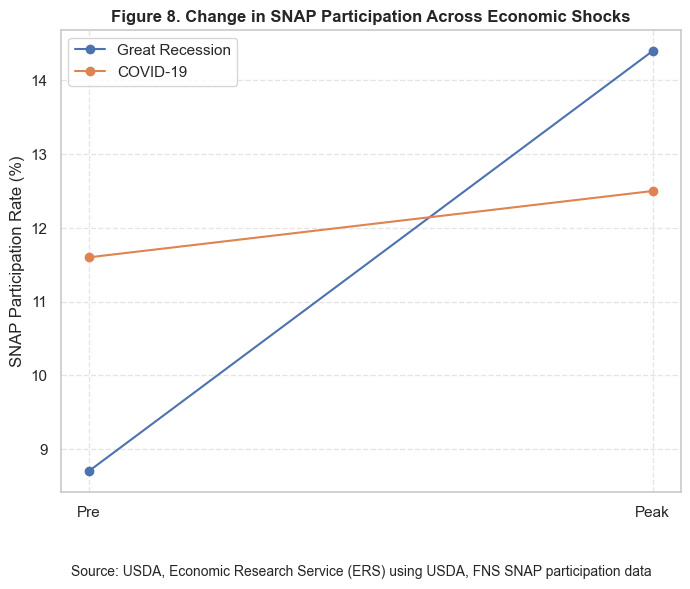

In [12]:
# Viz 8: Slope chart of economic shocks

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))

years = ["Pre", "Peak"]

snap_values = [
    Unemp_Data.loc[Unemp_Data["year"] == 2007, "snap_rate"].values[0],
    Unemp_Data.loc[Unemp_Data["year"] == 2011, "snap_rate"].values[0]
]

covid_values = [
    Unemp_Data.loc[Unemp_Data["year"] == 2019, "snap_rate"].values[0],
    Unemp_Data.loc[Unemp_Data["year"] == 2021, "snap_rate"].values[0]
]

plt.figure(figsize=(8,6))

plt.plot(years, snap_values, marker="o", label="Great Recession")
plt.plot(years, covid_values, marker="o", label="COVID-19")

plt.title("Figure 8. Change in SNAP Participation Across Economic Shocks", weight="bold")
plt.ylabel("SNAP Participation Rate (%)")

# Source caption
plt.figtext(
    0.5, -0.03,
    "Source: USDA, Economic Research Service (ERS) using USDA, FNS SNAP participation data",
    ha="center",
    fontsize=10
)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 2.5 SNAP Participation in Recession vs. Non-Recession Years

After examining this data, it is clear that SNAP participation tends to be higher during recession years, reinforcing its role as a countercyclical support program. Figure 9 compares the distribution of SNAP participation rates between recession and non-recession years. In this box plot, we see a wider range of SNAP participation over non-recession years compared to just the recession periods, suggesting greater variability in SNAP participation, and that participation depends on the severity of the economic shock. While there is some overlap between the two groups (recession/non-recession years), the smaller distribution during recession years reinforces SNAP’s role as a countercyclical safety net that expands in response to economic distress, but only in certain circumstances of economic downturn.

<Figure size 1000x600 with 0 Axes>

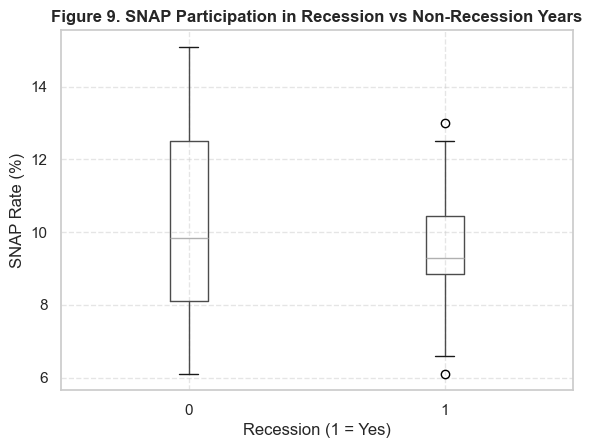

In [13]:
# Viz 9: Distribution of Snap Participation

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))

Unemp_Data.boxplot(column="snap_rate", by="recession")

plt.title("Figure 9. SNAP Participation in Recession vs Non-Recession Years", weight="bold")
plt.suptitle("")  # removes default title
plt.xlabel("Recession (1 = Yes)")
plt.ylabel("SNAP Rate (%)")

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

<div style="border-left: 4px solid #d95f02; padding: 10px; background-color: #FFD580;">
<strong>Box Plot Interpretation Help:</strong><br>
    
* Middle line - median SNAP participation <br>
* Box - middle 50% (IQR) <br>
* Whiskers - spread of typical values <br>
* Dots (if any) - outliers <br>
</div>

## Section 3: The Impact of SNAP

After examining historical SNAP trends and having established how SNAP responds to economic shocks, this section focuses on how the SNAP program translates into meaningful social outcomes, determined by related indicators. By comparing SNAP participation with poverty and food insecurity, we can better understand the program’s broader impact on economic well-being and the well-being of our neighbors.

### 3.1 Relationship between SNAP and Poverty

Looking at Figures 10 and 11, both aim to depict how poverty relates to SNAP participation and vice versa. SNAP participation rises during periods of increased poverty, suggesting again that the program expands in response to economic need. Comparing poverty and SNAP participation offers another window into visualizing how SNAP relates to different social indicators. It is widely understood that SNAP participation helps bring individuals and families out of poverty, and this chart goes to show why this is the reality when poverty and SNAP participation are closely correlated. 

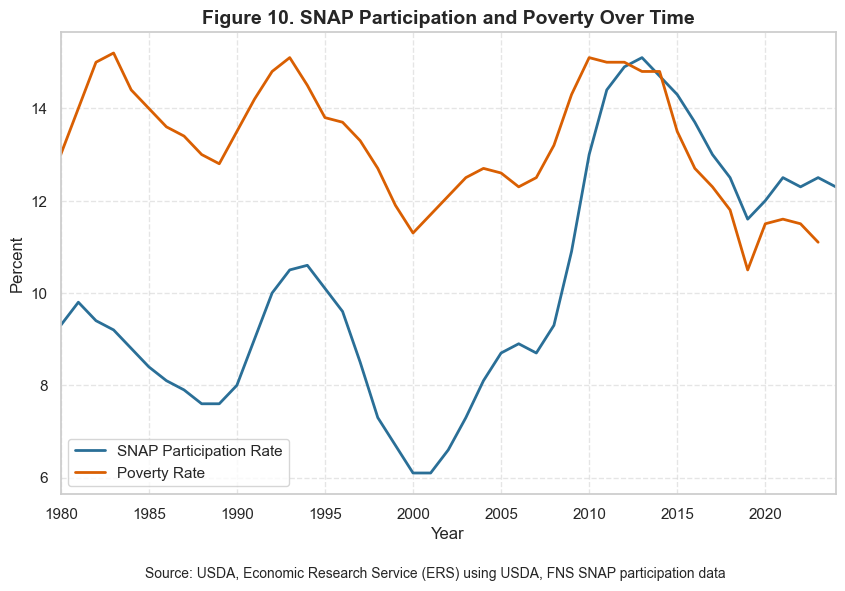

In [14]:
# Viz 10: SNAP and Poverty

# Theme + Sizing
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))

# Plotting
plt.plot(Unemp_Data["year"], Unemp_Data["snap_rate"], label="SNAP Participation Rate", color="#2a6f97", linewidth=2)
plt.plot(Unemp_Data["year"], Unemp_Data["poverty"], label="Poverty Rate", color="#d95f02", linewidth=2)

# Labeling
plt.title("Figure 10. SNAP Participation and Poverty Over Time", fontsize=14, weight="bold")
plt.xlabel("Year")
plt.ylabel("Percent")

# Formatting
plt.xlim(Unemp_Data["year"].min(), Unemp_Data["year"].max())
# # plt.ylim(COVID["snap_rate"].min(0), COVID["snap_rate"].max(12))

plt.legend()
plt.grid(alpha=0.3)

# Source caption
plt.figtext(
    0.5, -0.03,
    "Source: USDA, Economic Research Service (ERS) using USDA, FNS SNAP participation data",
    ha="center",
    fontsize=10
)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Figure 11 aims to ask a more in-depth question...

**When SNAP participation changes from year to year, how does poverty change alongside it?** 

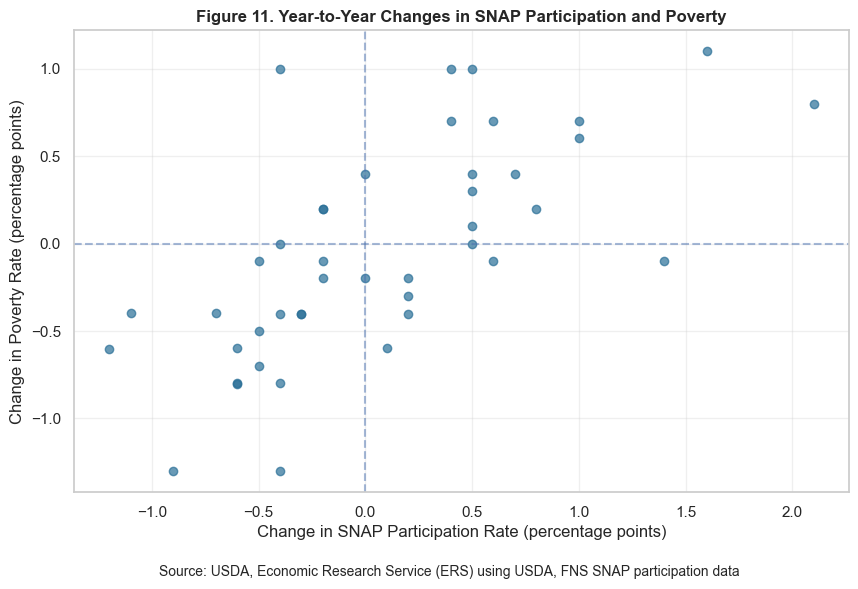

In [15]:
# Viz 11: SNAP and Poverty Scatter

# Theme + Sizing
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))

Unemp_Data["snap_change"] = Unemp_Data["snap_rate"].diff()
Unemp_Data["poverty_change"] = Unemp_Data["poverty"].diff()

plt.scatter(Unemp_Data["snap_change"], Unemp_Data["poverty_change"], alpha=0.7, color="#2a6f97")

plt.title("Figure 11. Year-to-Year Changes in SNAP Participation and Poverty", weight="bold")
plt.xlabel("Change in SNAP Participation Rate (percentage points)")
plt.ylabel("Change in Poverty Rate (percentage points)")

# Formatting
plt.axhline(0, linestyle="--", alpha=0.5)
plt.axvline(0, linestyle="--", alpha=0.5)
plt.grid(alpha=0.3)

# Source caption
plt.figtext(
    0.5, -0.03,
    "Source: USDA, Economic Research Service (ERS) using USDA, FNS SNAP participation data",
    ha="center",
    fontsize=10
)

plt.show()

Figure 11 uses a scatter plot to depict the year-to-year changes in SNAP participation and poverty. Most observations clustering in the top-right and bottom-left quadrants indicate that increases in SNAP participation tend to coincide with increases in poverty, while decreases in SNAP participation align with reductions in poverty. This reinforces the idea that SNAP responds dynamically to changing economic conditions, where poverty is a useful indicator of poor economic conditions. 

While this pattern indicates that SNAP is strongly correlated with broader economic conditions, it also highlights the program’s role as a reactive safety net, expanding when need increases and contracting as conditions improve. A smaller number of observations in the opposing quadrants suggests that policy changes or lag effects may occasionally decouple SNAP participation from immediate changes in poverty.

Importantly, this figure reflects correlation rather than causation. While SNAP participation rises alongside poverty, the presence of observations where SNAP increases while poverty declines suggests that the program may help mitigate the severity of economic hardship in certain periods.

**Analysis Key:**

* Top Right ( + , + ) = SNAP ↑ and Poverty ↑, Happens during economic downturns
* Bottom Left ( − , − ) = SNAP ↓ and Poverty ↓, Happens during economic recoveries
* Top Left ( − , + ) = SNAP ↓ but Poverty ↑, Potential policy gaps / lag effects
* Bottom Right ( + , − ) = SNAP ↑ but Poverty ↓, Could suggest protective effect of SNAP

### 3.2 Variability of SNAP Participation

Figure 12 shows the distribution of SNAP participation rates across all years, illustrating the values of SNAP participation that are typical. There is no clear distribution trend, as there is no strong right or left skew; however, the mean line assists in understanding how many years of SNAP participation were unusual in the context of the history of the program.

Unlike the time-series visualizations shown earlier, this distribution highlights the overall shape of SNAP participation across decades. The presence of what could be considered (vaguely) a longer upper tail confirms that high-participation years are rarer but significant, aligning with periods of economic crisis discussed in Section 2.

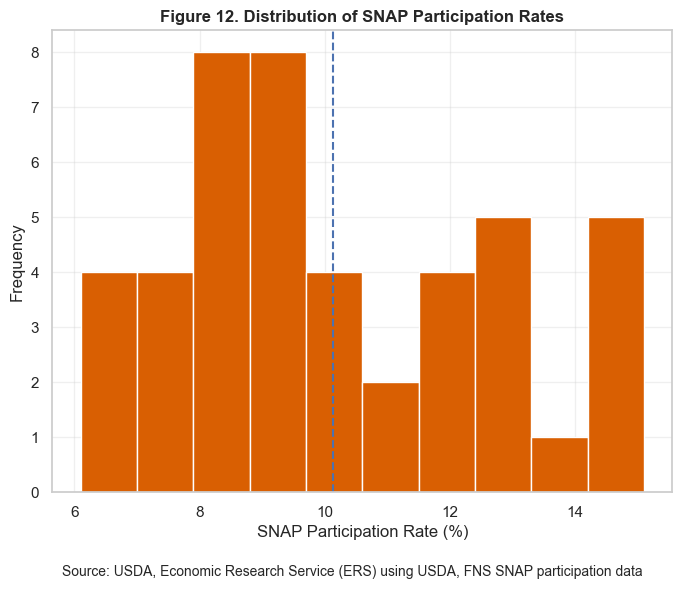

In [16]:
plt.figure(figsize=(8,6))

plt.hist(Unemp_Data["snap_rate"], bins=10, color = "#d95f02")

plt.title("Figure 12. Distribution of SNAP Participation Rates", weight="bold")
plt.xlabel("SNAP Participation Rate (%)")
plt.ylabel("Frequency")

plt.axvline(
    Unemp_Data["snap_rate"].mean(),
    linestyle="--"
)

# Source caption
plt.figtext(
    0.5, -0.03,
    "Source: USDA, Economic Research Service (ERS) using USDA, FNS SNAP participation data",
    ha="center",
    fontsize=10
)

plt.grid(alpha=0.3)
plt.show()

### 3.3 Comparing Social Indicators

Figure 13 presents small multiples charts comparing SNAP participation, poverty rates, and food insecurity from 2000 to 2025. Across all three measures, clear increases are visible during periods of economic distress, particularly during the Great Recession and the COVID-19 pandemic, which are indicated by the shaded regions of the chart. 

These aligned trends highlight the close relationship between economic hardship and SNAP participation. Given that the three lines move together, we can conclude that all three respond to economic shocks. However, SNAP participation often remains elevated even as poverty and food insecurity begin to stabilize, suggesting that the program continues to provide support during recovery periods (a trend that many prior visualizations have touched on). This pattern reinforces SNAP’s role not only as a reactive safety net, but also as a stabilizing force that helps mitigate the persistence of economic hardship.


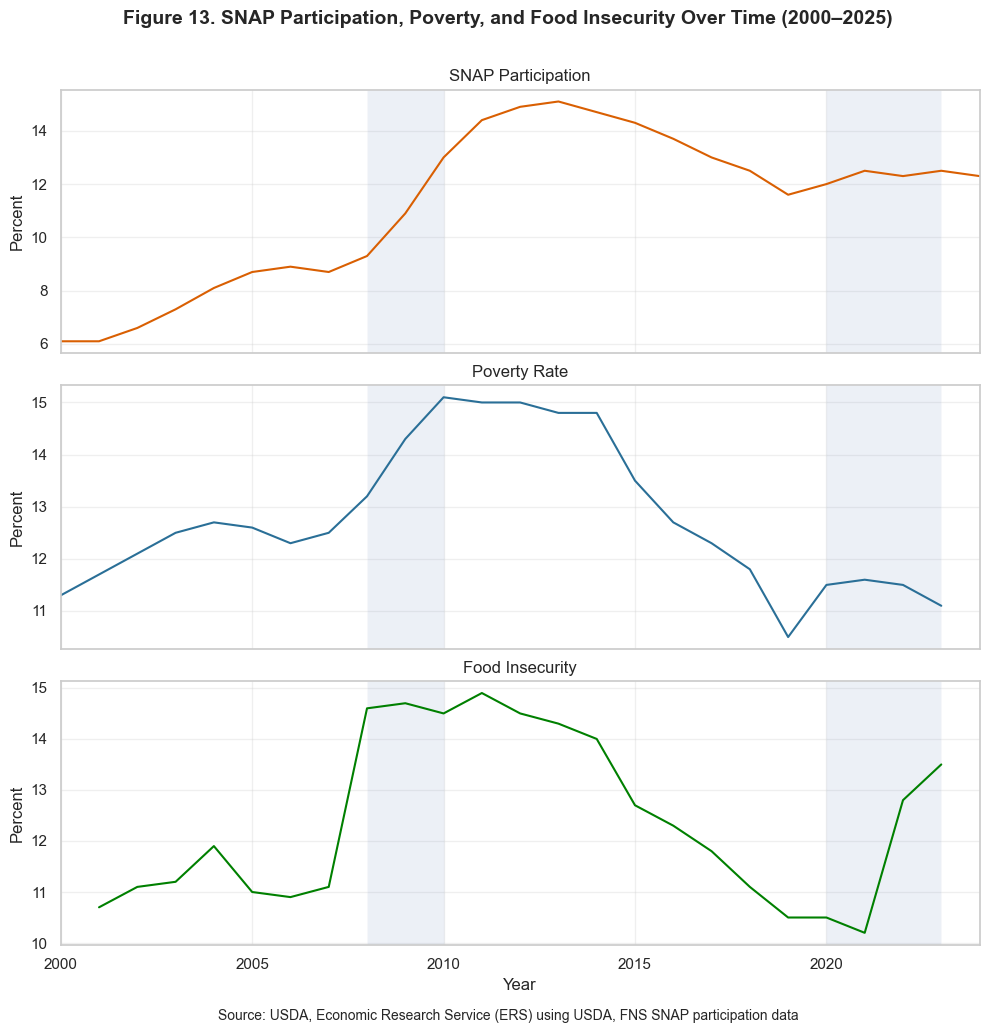

In [17]:
df_recent = Unemp_Data[(Unemp_Data["year"] >= 2000) & (Unemp_Data["year"] <= 2025)]

fig, axs = plt.subplots(3, 1, figsize=(10,10), sharex=True)
fig.suptitle(
    "Figure 13. SNAP Participation, Poverty, and Food Insecurity Over Time (2000–2025)",
    fontsize=14,
    weight="bold"
)
plt.tight_layout(rect=[0, 0, 1, 0.96])

axs[0].plot(df_recent["year"], df_recent["snap_rate"], color = "#d95f02")
axs[0].set_title("SNAP Participation")

axs[1].plot(df_recent["year"], df_recent["poverty"], color = "#2a6f97")
axs[1].set_title("Poverty Rate")

axs[2].plot(df_recent["year"], df_recent["food_insecurity"], color = "green")
axs[2].set_title("Food Insecurity")

for ax in axs:
    ax.grid(alpha=0.3)

axs[-1].set_xlabel("Year")
axs[-1].set_xticks(np.arange(2000, 2025, 5))
plt.xlim(df_recent["year"].min(), df_recent["year"].max())
axs[0].set_ylabel("Percent")
axs[1].set_ylabel("Percent")
axs[2].set_ylabel("Percent")

for ax in axs:
    ax.axvspan(2008, 2010, alpha=0.1)
    ax.axvspan(2020, 2023, alpha=0.1)

# Source caption
plt.figtext(
    0.5, -0.03,
    "Source: USDA, Economic Research Service (ERS) using USDA, FNS SNAP participation data",
    ha="center",
    fontsize=10
)

plt.show()

## Conclusion

This project examined SNAP trends at length, looking at participation rates, spending, and impacts of the program by utilizing USDA and BLS data. Through multiple visualizations, the historical context of the SNAP program, the impact of economic shocks, and the program's effect on other indicators of hunger and well-being were exemplified. It's clear that the importance of SNAP doesn't just lie in its mission of helping put food on the table for millions of Americans, but also supports our economy during economic downturns. In-depth visualizations of SNAP data, like those making up the foundation of this project, help put government programs and their effects into context; doing so visually makes trends more interpretable and transparent. Overall, SNAP is a highly valuable program that sits at the intersection of economic conditions and human well-being, rising alongside hardship and remaining elevated as a stabilizing support during recovery for Americans. This program should continue to be recognized and supported as a critical component of the United States’ social safety net, particularly as economic uncertainty persists. Ensuring its accessibility and effectiveness will remain essential to mitigating food insecurity and promoting economic resilience in the years ahead.

### Data Reflection

This project was a practice in demonstrating mastery of foundational visualization techniques. During the development of my project idea, I faced a lot of difficulty in understanding how to use the available SNAP data. Initially, this project was intended to be a case study on how SNAP responded to the COVID-19 pandemic, acting as an economic stabilizer for the economy. Unfortunately, the data provided by the USDA was convoluted and split too tediously to clean and wrangle for the allotted completion timeline of this project. Thus, I attempted to take a step back and examine the same program, SNAP, but from a different angle, which allowed for a much broader introspection into how SNAP has historically acted. 

When it came to cleaning my data, fortunately, a lot of the variables I used were  tidy from the USDA datasets and the [(Economic Research Service)](https://www.ers.usda.gov/topics/food-nutrition-assistance/supplemental-nutrition-assistance-program-snap/key-statistics-and-research). I cleaned my data mostly in Excel because of specific USDA thematic formatting. After, I was able to tidy it in Python to be  applicable and user-friendly for visualization. My data had a variety of labels (i.e., millions, billions, percent, percentage points), which was something I had to be extremely cognisant of when creating my visualizations to not be deceptive in my graphs. I also knew I wanted my color theme to be orange for this project, but I took note of keeping the same variables and the same colors for clarity throughout the project. 

I think the visualization that best communicated my point was my line chart in Figure 5, showing "SNAP Participation and Unemployment During Recessions." Adding shaded regions for the recession periods made a big difference and was a major improvement I included from the previous graph using the same data in Figure 4. Additionally, I think my small multiples graph at the end of Figure 13, showing "SNAP Participation, Poverty, and Food Insecurity Over Time (2000–2025)," made my third section very strong when discussing how the SNAP program relates to other indicators. Both of these charts exemplified my main insight that SNAP is an incredibly important program, indicating important periods in our country's economic history and our societal well-being. This project hopes to show that SNAP is so much more than a program that combats U.S. food insecurity; it is vital to supporting all Americans.  